<a href="https://colab.research.google.com/github/yogeshne9i/Stock_Price_Analysis_Major/blob/main/03_ARIMA_Stationarity_and_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
### ARIMA_Stationarity_and_Forecasting

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [ ]:
df = pd.read_csv("US_Stock_Data.csv")

# Clean
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, format='mixed')
df = df.sort_values('Date')

# Select target
ts = df.set_index('Date')['Netflix_Price']

ts.head()

,Netflix_Price
Date,
2020-01-02,329.81
2020-01-03,325.90
2020-01-06,335.83
2020-01-07,330.75
2020-01-08,339.26


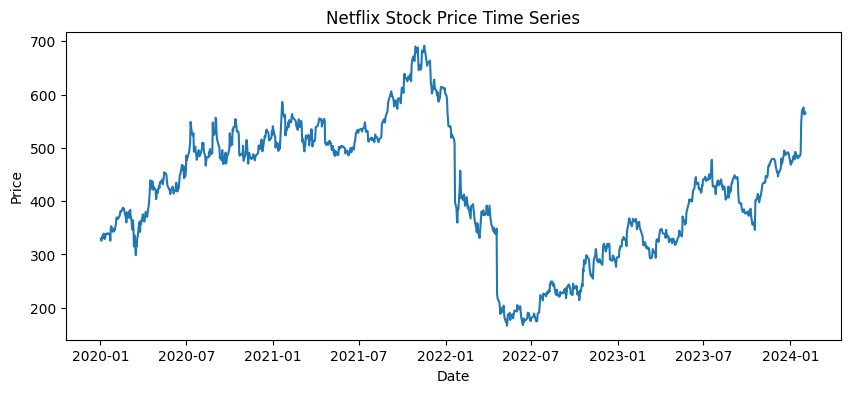

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ts)
plt.title("Netflix Stock Price Time Series")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


In [ ]:
#ADF Test
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] <= 0.05:
        print("✅ Series is stationary")
    else:
        print("❌ Series is NOT stationary")

adf_test(ts)


ADF Statistic: -1.4751039098851342
p-value: 0.5457891732491583
❌ Series is NOT stationary


In [ ]:
#Makeing Series Stationary
ts_diff = ts.diff().dropna()
adf_test(ts_diff)


ADF Statistic: -32.83699418352229
p-value: 0.0
✅ Series is stationary


In [ ]:
#Train-Test Split
train_size = int(len(ts_diff) * 0.8)
train, test = ts_diff[:train_size], ts_diff[train_size:]


In [ ]:
#Training ARIMA Model
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:          Netflix_Price   No. Observations:                  809
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3195.487
Date:                Mon, 05 Jan 2026   AIC                           6396.974
Time:                        15:35:45   BIC                           6411.057
Sample:                             0   HQIC                          6402.381
                                - 809                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0545      0.033     -1.655      0.098      -0.119       0.010
ma.L1         -0.9949      0.005   -219.790      0.000      -1.004      -0.986
sigma2       158.5283      2.697     58.772      0.0

In [ ]:
#Forecast & Evaluate
forecast = model_fit.forecast(steps=len(test))

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("ARIMA MAE:", mae)
print("ARIMA RMSE:", rmse)

ARIMA MAE: 6.482716236875971
ARIMA RMSE: 9.740675584248677


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


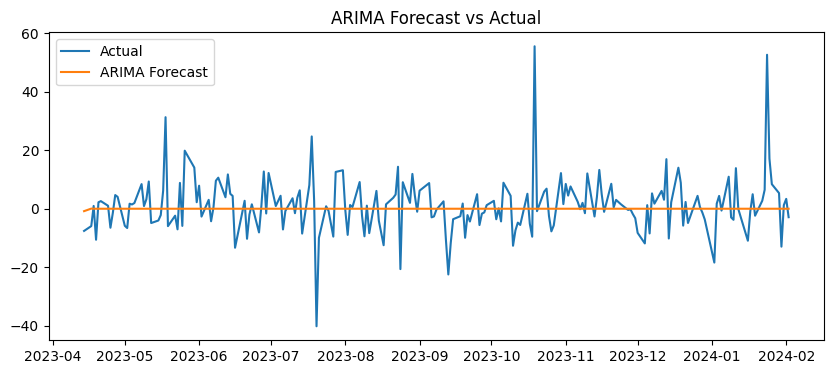

In [ ]:
#Ploting Forecast
plt.figure(figsize=(10,4))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, label="ARIMA Forecast")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.show()
